# Expansion Analysis

This notebook compares synthetic and real SWF power-flow results for one paired scenario contract across status quo, no-flex electrification, and HEMS operation. A readiness gate identifies incomplete runs, non-converged timesteps, temporal-contract mismatches, and missing expansion materializations before figures are used for publication.

Expansion costs currently come from the synthetic expansion materialization. Real SWF expansion costs are shown only after an equivalent real-grid materialization exists; they are never inferred from synthetic results.

In [ ]:
AGS = "9474126"  # Munich: "09162000", Forchheim: "9474126"
SCENARIO_PREFIX = "forchheim_paired_battery_tsam"
EXPECTED_GRID_COUNTS = {"Synthetic": 83, "Real SWF": 88}
REAL_PLZ = 91301

PLZ = None
SCENARIO_ID = None
POWERFLOW_CUTOFF_SCOPE = "grid"  # "asset" or "grid"
POWERFLOW_CUTOFF_PERCENTILE = 0.95  # Retained share: 0.95 removes the critical 5%.
POWERFLOW_CUTOFF_AXIS_PERCENTILES = (0.10, 0.25, 0.50, 0.75, 0.90, 1.0)
POWERFLOW_WORST_ASSET_PER_GRID = True
CABLE_DIAGNOSTIC_PERCENTILES = (0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99)
PAIRED_SCENARIO_OUTPUT_NAME = "swf_2045_paired_v3_91301_station_hybrid_v2"
EXCLUDED_REAL_LV_IDS = (113,)  # Temporary DSO clarification case; synthetic grids are unaffected.
SHOW_BUILDING_POINTS = False
SHOW_ENVELOPE_AXIS_TICKS = False

In [ ]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv


def find_postprocessing_dir() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "plotting").is_dir() and (candidate / "expansion").is_dir():
            return candidate
        nested = candidate / "GridExpand" / "5.postprocessing"
        if (nested / "plotting").is_dir() and (nested / "expansion").is_dir():
            return nested
    raise FileNotFoundError(
        "Could not find GridExpand/5.postprocessing from the notebook working directory."
    )


POSTPROCESSING_DIR = find_postprocessing_dir()
load_dotenv(POSTPROCESSING_DIR.parent / ".env", override=False)
if str(POSTPROCESSING_DIR) not in sys.path:
    sys.path.insert(0, str(POSTPROCESSING_DIR))

from audits.feeder_structure import (
    build_feeder_structure_comparison,
    export_feeder_structure_comparison,
)
from expansion.notebook_workflow import (
    expansion_cost_comparison_from_tables,
    expansion_cost_coverage_summary,
    expansion_cost_reduction_summary,
    export_scenario_analysis_manifest,
    load_cable_loading_decomposition,
    load_powerflow_cutoff_comparison,
    load_transformer_import_distributions_for_specs,
    load_voltage_summaries_for_powerflow_comparison,
    normalize_ags_string,
    prepare_expansion_analysis,
    reinforcement_catalog_summary,
)
from plotting import geoplotting
from plotting.feeder_structure import (
    plot_feeder_section_loading_percentiles,
    plot_feeder_structure_comparison,
)
from plotting.expansion_cost_plots import plot_expansion_cost_comparison_bar
from plotting.powerflow_asset_plots import (
    plot_cable_capacity_current_loading_comparison,
    plot_powerflow_asset_cutoff_overview_static,
)
from plotting.powerflow_io import save_plotly_figure
from plotting.powerflow_transformer import plot_transformer_import_distributions_matplotlib
from plotting.powerflow_voltage import plot_voltage_deviation_histogram_comparison

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

In [ ]:
analysis_context = prepare_expansion_analysis(
    scenario_prefix=SCENARIO_PREFIX,
    ags=AGS,
    expected_grid_counts=EXPECTED_GRID_COUNTS,
    real_plz=REAL_PLZ,
)

DISPLAY_LABEL = "Study region"
STAGE_LABELS = analysis_context["stage_labels"]
ANALYSIS_KEYS = analysis_context["analysis_keys"]
ANALYSIS_KEYS_BY_SOURCE = analysis_context["analysis_keys_by_source"]
SYNTHETIC_POWERFLOW_SUMMARY_SPECS = analysis_context["synthetic_specs"]
REAL_POWERFLOW_SUMMARY_SPECS = analysis_context["real_specs"]
expansion_tables_by_source = analysis_context["expansion_tables_by_source"]
analysis_meta_by_source = analysis_context["analysis_meta_by_source"]
# Synthetic aliases remain the input to the existing pylovo envelope maps.
expansion_tables_by_stage = expansion_tables_by_source["Synthetic"]
analysis_meta_by_stage = analysis_meta_by_source["Synthetic"]
available_analysis_keys = analysis_context["available_analysis_keys"]
missing_analysis_keys = analysis_context["missing_analysis_keys"]
DEFAULT_ANALYSIS_LABEL = analysis_context["default_analysis_label"]
expansion_tables = analysis_context["expansion_tables"]
analysis_key = analysis_context["analysis_key"]

COMPARISON_COLORS = {
    STAGE_LABELS["pre"]: "#2E7D32",
    STAGE_LABELS["post_no_flex"]: "#D62728",
    STAGE_LABELS["post_flex"]: "#1F77B4",
}
SOURCE_STYLE_MAP = {
    "Synthetic": {
        "linestyle": "-",
        "offset": -0.18,
        "alpha": 0.26,
        "marker_alpha": 0.42,
    },
    "Real SWF": {
        "linestyle": "--",
        "dashes": (3.0, 2.0),
        "offset": 0.18,
        "alpha": 0.18,
        "marker_alpha": 0.48,
    },
}

PAIRED_SCENARIO_DIR = (
    POSTPROCESSING_DIR.parent
    / "2.demand_allocation"
    / "gridalloc"
    / "outputs"
    / "scenario_calibration"
    / PAIRED_SCENARIO_OUTPUT_NAME
)

REAL_GRID_DATA_PATH = os.getenv(
    "GRID_DATA_PATH",
    "/home/breveron/data/swf_split_station_hybrid_v2",
)
OUTPUT_DIR = (
    POSTPROCESSING_DIR
    / "output"
    / "plots"
    / "expansion"
    / normalize_ags_string(AGS)
    / SCENARIO_PREFIX
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
manifest_paths = export_scenario_analysis_manifest(
    analysis_context,
    output_dir=OUTPUT_DIR,
    excluded_real_lv_ids=EXCLUDED_REAL_LV_IDS,
)

print(f"Selected region: {DISPLAY_LABEL} [AGS {normalize_ags_string(AGS)}]")
print(f"Scenario prefix: {SCENARIO_PREFIX}")
print(f"Output directory: {OUTPUT_DIR}")
display(analysis_context["powerflow_status"])
display(analysis_context["publication_gate"])
if not analysis_context["publication_ready"]:
    print(
        "DIAGNOSTIC DATA ONLY: at least one run/readiness check is incomplete. "
        "Figures may be inspected, but should not be reported as final results."
    )

Selected region: Study region [AGS 09474126]
Scenario prefix: forchheim_paired_battery_tsam
Output directory: /home/breveron/git/github/SurroGrid/GridExpand/5.postprocessing/output/plots/expansion/09474126/forchheim_paired_battery_tsam


,data_source,stage,run_name,expected_grids,launched_grids,summary_grids,pending_or_missing_summaries,grids_with_failed_timesteps,failed_timesteps,timestep_signatures,scenario_labels,profile_contracts,complete
0,Synthetic,status-quo,forchheim_paired_battery_tsam_synthetic_pre,83,83,83,0,0,0,1008,forchheim_paired_battery_tsam,physical_building_paired_v1,True
1,Synthetic,no-flex,forchheim_paired_battery_tsam_synthetic_no_flex,83,83,83,0,0,0,1008,forchheim_paired_battery_tsam,physical_building_paired_v1,True
2,Synthetic,HEMS,forchheim_paired_battery_tsam_synthetic_flex,83,83,83,0,0,0,1008,forchheim_paired_battery_tsam,physical_building_paired_v1,True
3,Real SWF,status-quo,forchheim_paired_battery_tsam_real_swf_pre,88,88,88,0,0,0,1008,forchheim_paired_battery_tsam,physical_building_paired_v1,True
4,Real SWF,no-flex,forchheim_paired_battery_tsam_real_swf_no_flex,88,88,88,0,3,240,1008,forchheim_paired_battery_tsam,physical_building_paired_v1,False
5,Real SWF,HEMS,forchheim_paired_battery_tsam_real_swf_flex,88,88,88,0,3,227,1008,forchheim_paired_battery_tsam,physical_building_paired_v1,False


,check,passed,detail
0,All six compact power-flow runs complete,False,513 grid-stage summaries; 467 failed timesteps
1,Shared temporal horizon,True,1008
2,Single scenario label,True,forchheim_paired_battery_tsam
3,Single paired profile contract,True,physical_building_paired_v1
4,Six matching synthetic/real expansion material...,True,6/6 available
5,All materialized grid costs complete,False,4 incomplete and 3 explicitly excluded grid-st...


DIAGNOSTIC DATA ONLY: at least one run/readiness check is incomplete. Figures may be inspected, but should not be reported as final results.


## Materialization Status

Power-flow figures can use partial compact summaries while a run is still progressing. Expansion-cost and envelope figures require materialized expansion analyses with keys derived from the same scenario prefix.

In [ ]:
display(analysis_context["analysis_status"])
missing_by_source = {
    source: context["missing_analysis_keys"]
    for source, context in analysis_context["expansion_context_by_source"].items()
    if context["missing_analysis_keys"]
}
if missing_by_source:
    print("Missing expansion materializations for this exact scenario:")
    for source, missing in missing_by_source.items():
        for label, key in missing.items():
            print(f"  - {source} / {label}: {key}")
else:
    print("Synthetic and real expansion materializations are available for all stages.")


,stage_label,analysis_key,available,data_source,run_name,stage,grids_with_expansion_summary,grids_total,grids_complete,grids_incomplete,grids_excluded,total_cost_eur
0,status-quo,forchheim_paired_battery_tsam_pre,True,Synthetic,forchheim_paired_battery_tsam_synthetic_pre,pre,83,83,83,0,0,0.000000e+00
1,no-flex,forchheim_paired_battery_tsam_post_no_flex,True,Synthetic,forchheim_paired_battery_tsam_synthetic_no_flex,post,83,83,83,0,0,1.673270e+06
2,HEMS,forchheim_paired_battery_tsam_post,True,Synthetic,forchheim_paired_battery_tsam_synthetic_flex,post,83,83,83,0,0,1.076413e+06
3,status-quo,forchheim_paired_battery_tsam_real_pre,True,Real SWF,forchheim_paired_battery_tsam_real_swf_pre,pre,87,88,87,0,1,6.067400e+04
4,no-flex,forchheim_paired_battery_tsam_real_post_no_flex,True,Real SWF,forchheim_paired_battery_tsam_real_swf_no_flex,post,85,88,85,2,1,1.820839e+06
5,HEMS,forchheim_paired_battery_tsam_real_post,True,Real SWF,forchheim_paired_battery_tsam_real_swf_flex,post,85,88,85,2,1,1.197572e+06


Synthetic and real expansion materializations are available for all stages.


## Expansion Cost Comparison

The bar chart compares materialized heuristic cable and transformer expansion costs for no-flex and HEMS operation. At present, the expansion materialization is synthetic-grid specific. Real SWF costs will appear only after equivalent real-grid expansion tables are available.

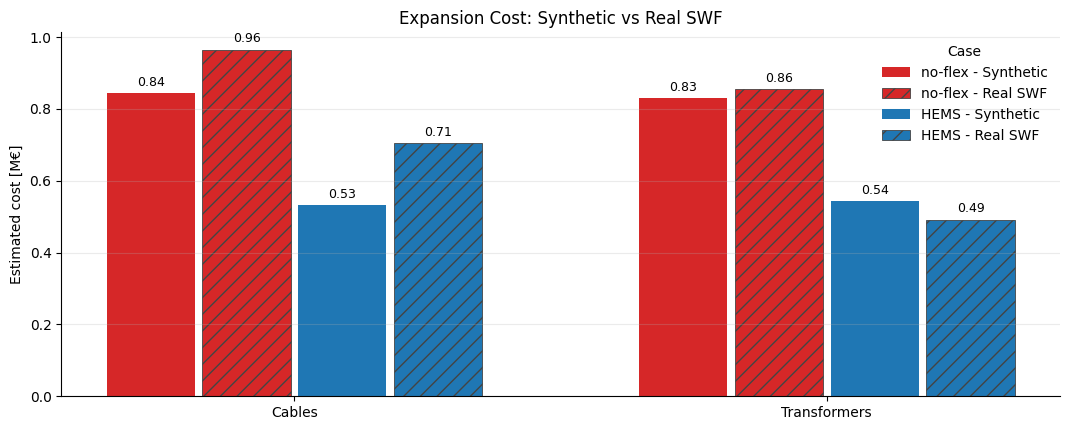

,stage,data_source,component,cost_eur
0,no-flex,Synthetic,Cables,843269.629625
1,no-flex,Synthetic,Transformers,830000.000000
2,HEMS,Synthetic,Cables,532412.764012
3,HEMS,Synthetic,Transformers,544000.000000
4,no-flex,Real SWF,Cables,964839.002415
5,no-flex,Real SWF,Transformers,856000.000000
6,HEMS,Real SWF,Cables,705571.999924
7,HEMS,Real SWF,Transformers,492000.000000


In [ ]:
cost_frames = []
for source in ("Synthetic", "Real SWF"):
    cost_frames.append(
        expansion_cost_comparison_from_tables(
            expansion_tables_by_source[source],
            analysis_meta_by_source[source],
            post_no_flex_label=STAGE_LABELS["post_no_flex"],
            post_flex_label=STAGE_LABELS["post_flex"],
            data_source=source,
        )
    )
expansion_cost_comparison = pd.concat(cost_frames, ignore_index=True)
if expansion_cost_comparison.empty:
    print("No matching expansion-cost materialization exists for this scenario yet.")
else:
    plot_expansion_cost_comparison_bar(
        expansion_cost_comparison,
        stage_order=(STAGE_LABELS["post_no_flex"], STAGE_LABELS["post_flex"]),
        color_map=COMPARISON_COLORS,
        output_path=OUTPUT_DIR / "post_flex_no_flex_synthetic_real_expansion_cost_bar",
        title="Expansion Cost: Synthetic vs Real SWF",
    )
display(expansion_cost_comparison)


In [ ]:
cost_reduction_summary = expansion_cost_reduction_summary(
    expansion_cost_comparison,
    post_no_flex_label=STAGE_LABELS["post_no_flex"],
    post_flex_label=STAGE_LABELS["post_flex"],
)
cost_coverage_summary = expansion_cost_coverage_summary(
    analysis_context["analysis_status"]
)
display(cost_reduction_summary)
display(cost_coverage_summary)

reinforcement_summary = reinforcement_catalog_summary(
    expansion_tables_by_source
)
display(reinforcement_summary)


,data_source,component,no_flex_cost_million_eur,flex_cost_million_eur,saving_million_eur,reduction_percent
0,Synthetic,Cables,0.84,0.53,0.31,36.9
1,Synthetic,Transformers,0.83,0.54,0.29,34.5
2,Synthetic,Total,1.67,1.08,0.60,35.7
3,Real SWF,Cables,0.96,0.71,0.26,26.9
4,Real SWF,Transformers,0.86,0.49,0.36,42.5
5,Real SWF,Total,1.82,1.20,0.62,34.2


,data_source,stage_label,grids_total,grids_complete,grids_incomplete,grids_excluded,total_cost_eur,cost_per_complete_grid_eur
0,Synthetic,status-quo,83,83,0,0,0.0,0.0
1,Synthetic,no-flex,83,83,0,0,1673270.0,20160.0
2,Synthetic,HEMS,83,83,0,0,1076413.0,12969.0
3,Real SWF,status-quo,88,87,0,1,60674.0,697.0
4,Real SWF,no-flex,88,85,2,1,1820839.0,21422.0
5,Real SWF,HEMS,88,85,2,1,1197572.0,14089.0


,data_source,stage_label,NAYY_4_150,NAYY_4_185,NAYY_4_240,added_capacity_ka
0,Synthetic,status-quo,0,0,0,0.000
1,Synthetic,no-flex,445,2,1,121.133
2,Synthetic,HEMS,275,1,0,74.563
3,Real SWF,status-quo,11,0,0,2.970
4,Real SWF,no-flex,245,5,7,70.214
5,Real SWF,HEMS,176,7,6,51.853


## Synthetic and Real Power-Flow Stress

The retained-cutoff comparison uses compact summaries from the exact scenario prefix selected above. POWERFLOW_CUTOFF_SCOPE applies the cutoff to pooled assets or grids; POWERFLOW_WORST_ASSET_PER_GRID chooses between one critical asset per grid and all retained assets. Partial runs remain visible, but the readiness table above marks them as diagnostic.

,data_source,comparison_stage,grids
0,Real SWF,status-quo,87
3,Synthetic,status-quo,83
1,Real SWF,no-flex,87
4,Synthetic,no-flex,83
2,Real SWF,HEMS,87
5,Synthetic,HEMS,83


Temporarily excluded real SWF grids:


,comparison_stage,excluded_lv_ids,excluded_grids
0,status-quo,LV_113,1
1,no-flex,LV_113,1
2,HEMS,LV_113,1


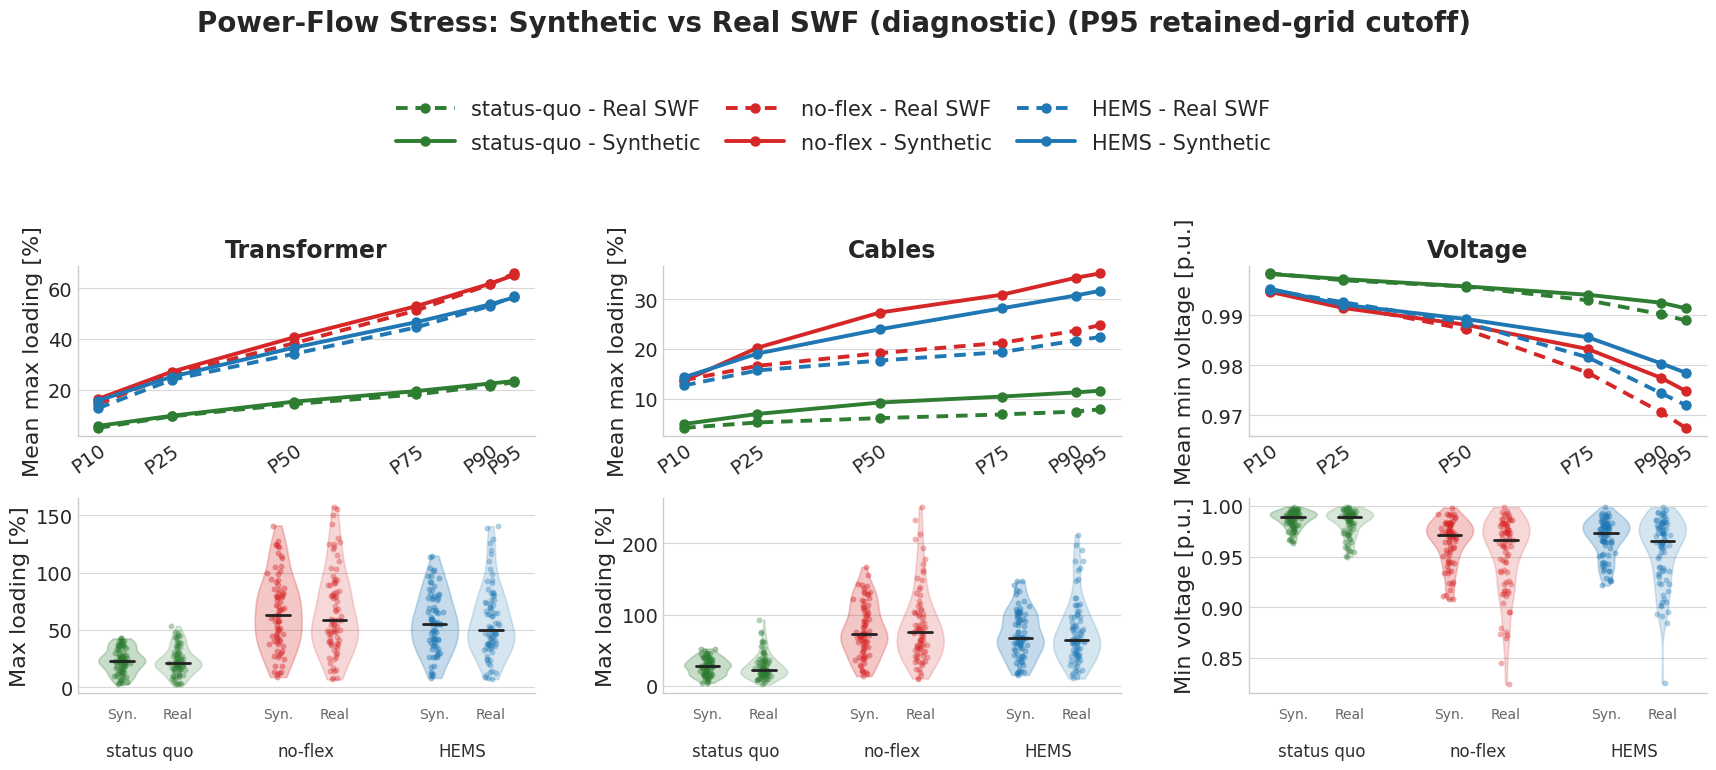

In [ ]:
powerflow_profile = pd.DataFrame()
synthetic_summary = pd.DataFrame()
coverage_summary = pd.DataFrame()
if analysis_context["powerflow_status"]["summary_grids"].sum() == 0:
    print("No compact power-flow summaries exist for this scenario yet.")
else:
    powerflow_comparison = load_powerflow_cutoff_comparison(
        synthetic_specs=SYNTHETIC_POWERFLOW_SUMMARY_SPECS,
        real_specs=REAL_POWERFLOW_SUMMARY_SPECS,
        stage_order=list(STAGE_LABELS.values()),
        ags=AGS,
        scenario_id=SCENARIO_ID,
        plz=PLZ,
        real_plz=REAL_PLZ,
        excluded_real_lv_ids=EXCLUDED_REAL_LV_IDS,
    )
    powerflow_profile = powerflow_comparison["profile"]
    synthetic_summary = powerflow_comparison["asset_summary"]
    coverage_summary = powerflow_comparison["coverage_summary"]
    excluded_real_grids = powerflow_comparison["excluded_real_grids"]
    display(coverage_summary)
    if not excluded_real_grids.empty:
        print("Temporarily excluded real SWF grids:")
        display(excluded_real_grids)

    plotted_stages = [
        stage
        for stage in STAGE_LABELS.values()
        if stage in set(powerflow_profile["comparison_stage"].dropna())
    ]
    readiness_suffix = "" if analysis_context["publication_ready"] else " (diagnostic)"
    fig = plot_powerflow_asset_cutoff_overview_static(
        powerflow_profile,
        group_col="comparison_stage",
        source_col="data_source",
        source_style_map=SOURCE_STYLE_MAP,
        color_map={
            label: COMPARISON_COLORS[label]
            for label in plotted_stages
            if label in COMPARISON_COLORS
        },
        asset_cutoff_percentile=POWERFLOW_CUTOFF_PERCENTILE,
        asset_percentiles=POWERFLOW_CUTOFF_AXIS_PERCENTILES,
        filter_scope=POWERFLOW_CUTOFF_SCOPE,
        worst_asset_per_grid=POWERFLOW_WORST_ASSET_PER_GRID,
        figsize=(18.0, 9.5),
        title=(
            f"Power-Flow Stress: Synthetic vs Real SWF"
            f"{readiness_suffix}"
        ),
        save_path=(
            OUTPUT_DIR
            / "pre_post_flex_no_flex_synthetic_real_asset_cutoff_overview"
        ),
    )
    plt.show()

    for source, skipped in powerflow_comparison["skipped"].items():
        if skipped:
            print(f"Skipped missing {source} compact power-flow summaries:")
            for label, reason in skipped.items():
                print(f"  - {label}: {reason}")

### Cable Capacity and Transported Current

These percentile curves use the same analyzed cable rows as the loading comparison. Capacity alone cannot explain loading: the middle panel shows the annual peak current transported through each cable, while the right panel combines current and installed ampacity.

,data_source,comparison_stage,cables,grids,median_capacity_a,median_peak_current_a,median_max_loading_percent
0,Real SWF,HEMS,8918,87,276.0,41.7,15.8
1,Real SWF,no-flex,8918,87,276.0,45.0,16.9
2,Real SWF,status-quo,8918,87,276.0,14.0,5.2
3,Synthetic,HEMS,8481,83,242.0,64.3,24.5
4,Synthetic,no-flex,8481,83,242.0,70.8,27.0
5,Synthetic,status-quo,8460,83,242.0,23.1,8.8


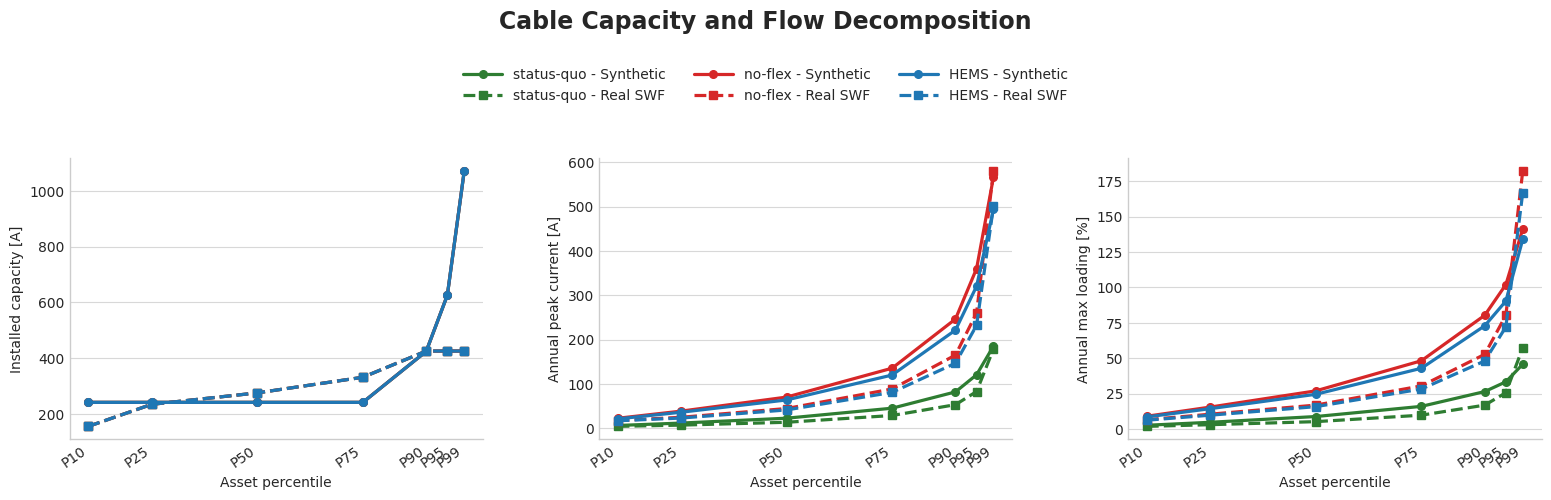

In [ ]:
cable_decomposition = load_cable_loading_decomposition(
    synthetic_specs=SYNTHETIC_POWERFLOW_SUMMARY_SPECS,
    real_specs=REAL_POWERFLOW_SUMMARY_SPECS,
    ags=AGS,
    real_plz=REAL_PLZ,
    excluded_real_lv_ids=EXCLUDED_REAL_LV_IDS,
)
if cable_decomposition.empty:
    print("No cable summaries exist for this scenario yet.")
else:
    cable_decomposition_summary = (
        cable_decomposition.groupby(
            ["data_source", "comparison_stage"],
            observed=True,
            as_index=False,
        )
        .agg(
            cables=("asset_id", "count"),
            grids=("grid", "nunique"),
            median_capacity_a=("installed_capacity_a", "median"),
            median_peak_current_a=("max_current_a", "median"),
            median_max_loading_percent=("max_loading_percent", "median"),
        )
        .round(1)
    )
    display(cable_decomposition_summary)
    cable_fig = plot_cable_capacity_current_loading_comparison(
        cable_decomposition,
        stage_order=tuple(STAGE_LABELS.values()),
        color_map=COMPARISON_COLORS,
        asset_percentiles=CABLE_DIAGNOSTIC_PERCENTILES,
        title="Cable Capacity and Flow Decomposition",
        save_path=OUTPUT_DIR / "cable_capacity_current_loading_comparison",
    )
    plt.show()


## Feeder Structure and Physical Cable Corridors

This audit compares the paired annual demand on graph-normalized feeder structures. Parallel physical cable rows between the same buses form one electrical edge; degree-two chains without allocated demand form one feeder section. Terminal service connections and SWF NS_StLt control-line placeholders are excluded from physical-cable metrics. Observed loading still comes from the existing power-flow run, so the few control rows parallel to physical cables remain a documented contamination until that run is repeated.

In [ ]:
feeder_comparison = build_feeder_structure_comparison(
    synthetic_specs=SYNTHETIC_POWERFLOW_SUMMARY_SPECS,
    real_specs=REAL_POWERFLOW_SUMMARY_SPECS,
    paired_dir=PAIRED_SCENARIO_DIR,
    ags=AGS,
    real_plz=REAL_PLZ,
    excluded_real_lv_ids=EXCLUDED_REAL_LV_IDS,
)
feeder_audit_dir = (
    POSTPROCESSING_DIR
    / "output"
    / "audits"
    / "feeder_structure"
    / normalize_ags_string(AGS)
    / SCENARIO_PREFIX
)
export_feeder_structure_comparison(feeder_comparison, feeder_audit_dir)

feeder_grid_metrics = feeder_comparison["grid_metrics"]
feeder_summary_metrics = [
    "outgoing_feeders",
    "feeder_sections",
    "median_downstream_demand_per_capacity_kwh_per_a",
    "downstream_demand_weighted_capacity_a",
    "demand_weighted_section_depth",
    "demand_weighted_path_length_km",
]
display(
    feeder_grid_metrics.groupby("data_source", observed=True)[feeder_summary_metrics]
    .median()
    .round(2)
    .T
)
control_lines = feeder_comparison["control_lines"]
if not control_lines.empty:
    display(
        control_lines.groupby(["data_source", "control_role"], observed=True)
        .agg(line_rows=("line_id", "nunique"), grids=("grid", "nunique"))
    )

plot_feeder_structure_comparison(
    feeder_grid_metrics,
    save_path=OUTPUT_DIR / "synthetic_real_feeder_structure",
)
plt.show()
plot_feeder_section_loading_percentiles(
    feeder_comparison["section_loading"],
    stage_order=tuple(STAGE_LABELS.values()),
    color_map=COMPARISON_COLORS,
    save_path=OUTPUT_DIR / "synthetic_real_physical_section_loading",
)
plt.show()

## Temporal and Flow Diagnostics

The voltage comparison uses compact summaries for both network sources. Transformer-import diagnostics remain synthetic-only because the real SWF compact schema does not store the matching signed transformer-import time series. The cable decomposition below directly tests whether a loading difference comes from ampacity, transported peak current, or both.

In [ ]:
voltage_summaries = load_voltage_summaries_for_powerflow_comparison(
    synthetic_specs=SYNTHETIC_POWERFLOW_SUMMARY_SPECS,
    real_specs=REAL_POWERFLOW_SUMMARY_SPECS,
    ags=AGS,
    scenario_id=SCENARIO_ID,
    plz=PLZ,
    real_plz=REAL_PLZ,
    excluded_real_lv_ids=EXCLUDED_REAL_LV_IDS,
)
if not voltage_summaries:
    print("No voltage summaries exist for this scenario yet.")
else:
    voltage_fig = plot_voltage_deviation_histogram_comparison(
        voltage_summaries,
        lower_limit=0.95,
        upper_limit=1.03,
        show=False,
    )
    try:
        save_plotly_figure(
            voltage_fig,
            OUTPUT_DIR / "pre_post_flex_no_flex_voltage_deviation_histogram",
            formats=("svg", "png"),
            width=1370,
            height=720,
        )
    except RuntimeError as exc:
        print(f"Could not export voltage histogram: {exc}")
    display(voltage_fig)

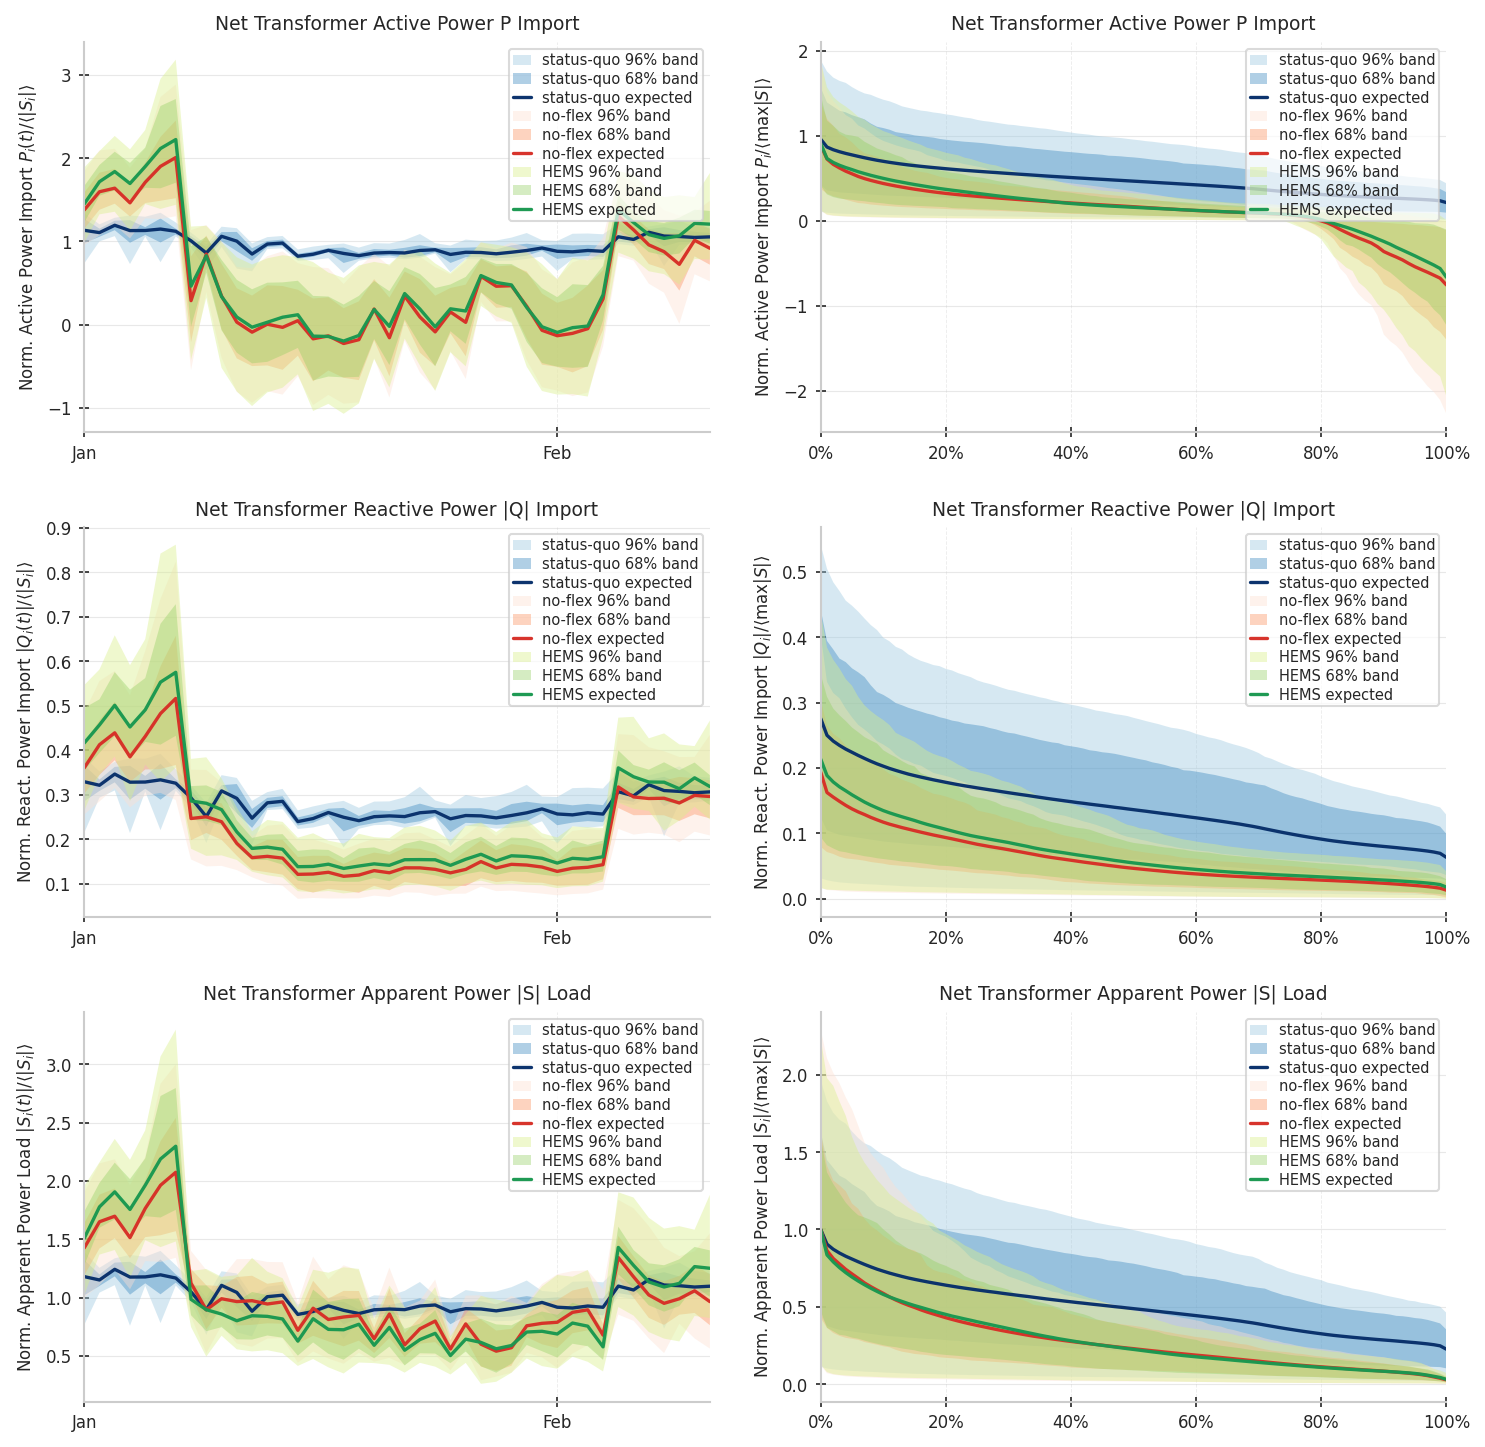

In [ ]:
transformer_distribution = load_transformer_import_distributions_for_specs(
    SYNTHETIC_POWERFLOW_SUMMARY_SPECS,
    ags=AGS,
    scenario_id=SCENARIO_ID,
    plz=PLZ,
)
if transformer_distribution.empty:
    print("No synthetic transformer-import diagnostics exist for this scenario yet.")
else:
    transformer_fig = plot_transformer_import_distributions_matplotlib(
        transformer_distribution,
        metrics=("p", "q", "s"),
        group_col="comparison_stage",
        tsam_week_panels=False,
        show=False,
    )
    transformer_fig.savefig(
        OUTPUT_DIR / "pre_post_flex_no_flex_transformer_import_distributions.svg",
        bbox_inches="tight",
    )
    plt.show()

## Expansion Cost Envelopes

The maps use only materialized expansion costs from the exact selected scenario. Synthetic and real network geometries share the synthetic reference extent so the two rows are spatially comparable. They are skipped while materializations are absent.

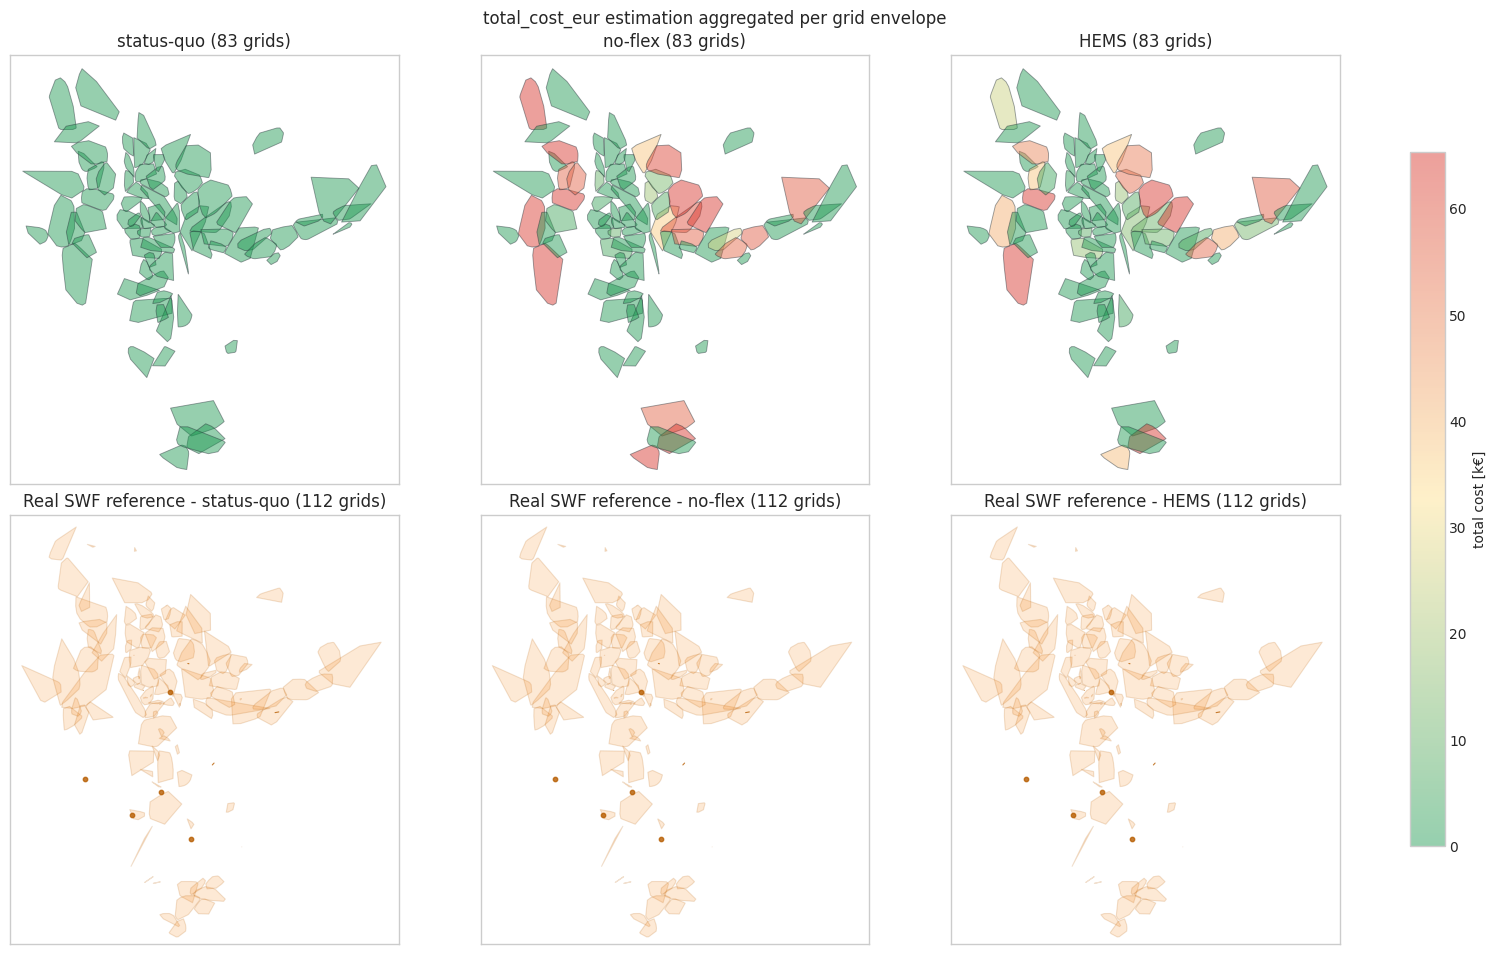

In [ ]:
BUILDING_POINT_SIZE = 1.2
BUILDING_POINT_ALPHA = 0.06
total_envelope_data = {}
if not available_analysis_keys:
    print("No matching expansion materialization exists; envelope maps are skipped.")
else:
    fig, axes, total_envelope_data = geoplotting.plot_synthetic_expansion_envelope_panels(
        analysis_keys=available_analysis_keys,
        value_column="total_cost_eur",
        clip_quantile=0.95,
        log_scale=False,
        cmap="cost_green_red",
        show_buildings=SHOW_BUILDING_POINTS,
        show_axis_ticks=SHOW_ENVELOPE_AXIS_TICKS,
        add_osm_layer=False,
        building_point_size=BUILDING_POINT_SIZE,
        building_alpha=BUILDING_POINT_ALPHA,
        ncols=3,
        real_grid_data_path=REAL_GRID_DATA_PATH,
        real_load_type="HH",
        output_path=OUTPUT_DIR / "pre_post_flex_no_flex_total_cost_envelopes.svg",
    )
    plt.show()

## Summary Tables

Compact table outputs for the materialized expansion analysis and the plotted diagnostics.


In [ ]:
if expansion_tables is None:
    print("No matching expansion materialization exists for this scenario.")
else:
    display(expansion_tables["analysis_run"])

,expansion_analysis_run_id,analysis_key,assumption_key,run_name,stage,scenario_id,ags,plz,data_source,created_at,note
0,38,forchheim_paired_battery_tsam_post,de_lv_heuristic_2026,forchheim_paired_battery_tsam_synthetic_flex,post,None,9474126,91301,Synthetic,2026-07-21 08:05:16.614361+00:00,


In [ ]:
if expansion_tables is None:
    print("No matching expansion materialization exists for this scenario.")
else:
    display(expansion_tables["cost_summary"])

,data_source,grids_with_line_rows,cable_segments,cable_segments_requiring_expansion,cable_segments_overloaded,reinforcement_150_count,reinforcement_185_count,reinforcement_240_count,reinforcement_added_capacity_ka,cable_cost_eur,transformers,transformers_requiring_expansion,transformers_overloaded,transformer_cost_eur,grids_total,grids_complete,grids_incomplete,grids_excluded,total_cost_eur
0,Synthetic,83,1165,65,65,275,1,0,74.563,532412.764012,83,13,10,544000.0,83,83,0,0,1.076413e+06


In [ ]:
if expansion_tables is None:
    print("No matching expansion materialization exists for this scenario.")
else:
    display(expansion_tables["grid_cost_summary"].head(10))

,data_source,source_grid_id,grid_label,grid_case_id,real_grid_case_id,plz,kcid,bcid,cable_segments,cable_segments_requiring_expansion,reinforcement_150_count,reinforcement_185_count,reinforcement_240_count,reinforcement_added_capacity_ka,cable_cost_eur,max_cable_loading_percent,transformer_rated_power_kva,required_transformer_kva,additional_transformer_kva,transformer_requires_expansion,transformer_cost_eur,transformer_loading_percent,cost_status,n_failed_timesteps,status_reason,total_cost_eur
0,Synthetic,1905,91301-10-9,1905,None,91301,10,9,28,11,49,0,0,13.230,88861.157349,146.999112,630.0,750.0,120.0,True,42000.0,118.105998,complete,0,None,130861.157349
1,Synthetic,1622,91301-1-5,1622,None,91301,1,5,31,10,33,0,0,8.910,64351.536100,174.453088,630.0,800.0,170.0,True,42000.0,125.482471,complete,0,None,106351.536100
2,Synthetic,1894,91301-10-5,1894,None,91301,10,5,26,3,12,1,0,3.553,42475.528787,177.640246,630.0,900.0,270.0,True,48000.0,138.177609,complete,0,None,90475.528787
3,Synthetic,1654,91301-2-5,1654,None,91301,2,5,31,3,10,0,0,2.700,26247.238107,147.286743,630.0,650.0,20.0,True,42000.0,101.319719,complete,0,None,68247.238107
4,Synthetic,1861,91301-9-6,1861,None,91301,9,6,33,2,6,0,0,1.620,23977.337210,107.524303,630.0,750.0,120.0,True,42000.0,113.305376,complete,0,None,65977.337210
5,Synthetic,1686,91301-3-3,1686,None,91301,3,3,41,3,5,0,0,1.350,15977.100808,128.897673,630.0,700.0,70.0,True,42000.0,103.717544,complete,0,None,57977.100808
6,Synthetic,1918,91301-11-3,1918,None,91301,11,3,17,4,52,0,0,14.040,55081.930497,153.135977,630.0,630.0,0.0,False,0.0,81.086496,complete,0,None,55081.930497
7,Synthetic,1834,91301-7-11,1834,None,91301,7,11,18,1,4,0,0,1.080,13031.037699,142.307271,630.0,650.0,20.0,True,42000.0,97.221211,complete,0,None,55031.037699
8,Synthetic,1838,91301-7-12,1838,None,91301,7,12,29,2,7,0,0,1.890,9533.675343,104.566466,630.0,650.0,20.0,True,42000.0,102.320463,complete,0,None,51533.675343
9,Synthetic,1634,91301-2-3,1634,None,91301,2,3,40,2,2,0,0,0.540,7741.134727,104.914193,630.0,800.0,170.0,True,42000.0,124.189004,complete,0,None,49741.134727


In [ ]:
if expansion_tables is None:
    print("No matching expansion materialization exists for this scenario.")
else:
    display(expansion_tables["cable_summary_by_type"])

,visible_std_type,cable_segments,cable_segments_requiring_expansion,length_km,reinforcement_150_count,reinforcement_185_count,reinforcement_240_count,reinforcement_added_capacity_ka,estimated_cost_eur,max_loading_percent
0,NAYY_4_120,1004,35,127.536473,144,0,0,38.880,294194.235174,174.453088
1,NAYY_4_185,51,13,10.537549,82,0,0,22.140,104426.237704,151.782633
2,NAYY_4_300,36,6,9.803241,31,0,0,8.370,73111.197002,152.423029
3,NAYY_4_240,41,6,10.920940,13,1,0,3.823,41151.951604,177.640246
4,NAYY_4_150,32,5,5.131065,5,0,0,1.350,19529.142528,138.509446
5,NAYY_4_50,1,0,0.017310,0,0,0,0.000,0.000000,88.672565


In [ ]:
if expansion_tables is None:
    print("No matching expansion materialization exists for this scenario.")
else:
    display(expansion_tables["transformer_summary_by_basis"])

,transformer_cost_basis,transformers,transformers_requiring_expansion,additional_transformer_kva,estimated_cost_eur,max_loading_percent
0,all_in_replacement_to_800kva,10,10,750.0,420000.0,125.482471
1,all_in_replacement_to_630kva,2,2,200.0,76000.0,116.594672
2,all_in_replacement_to_1000kva,1,1,270.0,48000.0,138.177609
3,none_existing_capacity_sufficient,70,0,0.0,0.0,91.829336


### Power-Flow Stress Input Coverage


In [ ]:
if synthetic_summary.empty:
    print("No power-flow stress input coverage is available yet.")
else:
    display(synthetic_summary)

,data_source,comparison_stage,metric,asset_type,assets,grids
0,Real SWF,status-quo,Cables,cable,44590,87
1,Real SWF,status-quo,Transformer,transformer,435,87
2,Real SWF,status-quo,Voltage,bus,33750,87
9,Synthetic,status-quo,Cables,cable,42300,83
10,Synthetic,status-quo,Transformer,transformer,415,83
11,Synthetic,status-quo,Voltage,bus,31345,83
3,Real SWF,no-flex,Cables,cable,44590,87
4,Real SWF,no-flex,Transformer,transformer,435,87
5,Real SWF,no-flex,Voltage,bus,33750,87
12,Synthetic,no-flex,Cables,cable,42405,83


### Voltage Summary Sample


In [ ]:
voltage_sample_frames = []
for source, source_summaries in voltage_summaries.items():
    for stage_label, summary in source_summaries.items():
        voltage_sample_frames.append(
            summary.assign(data_source=source, comparison_stage=stage_label)
        )
if voltage_sample_frames:
    voltage_summary = pd.concat(voltage_sample_frames, ignore_index=True, sort=False)
    display(voltage_summary.head(10))
else:
    print("Run the voltage diagnostic cell after summaries become available.")

/tmp/ipykernel_2901608/3203750634.py:8: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,grid,powerflow_run_id,run_name,scenario_id,scenario_key,stage,ags,plz,kcid,bcid,pylovo_grid_result_id,n_timesteps,n_buses,min_vm_pu,max_vm_pu,data_source,comparison_stage
0,09474126-91301_1_3,4149.0,forchheim_paired_battery_tsam_synthetic_pre,1.0,baseline_static,pre,9474126.0,91301.0,1.0,3.0,199.0,1008,142,0.957939,0.999996,Synthetic,status-quo
1,09474126-91301_1_5,4151.0,forchheim_paired_battery_tsam_synthetic_pre,1.0,baseline_static,pre,9474126.0,91301.0,1.0,5.0,201.0,1008,159,0.967584,0.999993,Synthetic,status-quo
2,09474126-91301_2_4,4153.0,forchheim_paired_battery_tsam_synthetic_pre,1.0,baseline_static,pre,9474126.0,91301.0,2.0,4.0,205.0,1008,53,0.992733,0.999997,Synthetic,status-quo
3,09474126-91301_1_2,4158.0,forchheim_paired_battery_tsam_synthetic_pre,1.0,baseline_static,pre,9474126.0,91301.0,1.0,2.0,198.0,1008,146,0.951062,0.999992,Synthetic,status-quo
4,09474126-91301_2_2,4160.0,forchheim_paired_battery_tsam_synthetic_pre,1.0,baseline_static,pre,9474126.0,91301.0,2.0,2.0,203.0,1008,8,0.984182,0.999998,Synthetic,status-quo
5,09474126-91301_1_4,4164.0,forchheim_paired_battery_tsam_synthetic_pre,1.0,baseline_static,pre,9474126.0,91301.0,1.0,4.0,200.0,1008,72,0.988210,0.999924,Synthetic,status-quo
6,09474126-91301_2_3,4167.0,forchheim_paired_battery_tsam_synthetic_pre,1.0,baseline_static,pre,9474126.0,91301.0,2.0,3.0,204.0,1008,201,0.974773,0.999777,Synthetic,status-quo
7,09474126-91301_2_6,4168.0,forchheim_paired_battery_tsam_synthetic_pre,1.0,baseline_static,pre,9474126.0,91301.0,2.0,6.0,207.0,1008,92,0.981557,0.999993,Synthetic,status-quo
8,09474126-91301_2_5,4173.0,forchheim_paired_battery_tsam_synthetic_pre,1.0,baseline_static,pre,9474126.0,91301.0,2.0,5.0,206.0,1008,155,0.975684,0.999996,Synthetic,status-quo
9,09474126-91301_2_8,4175.0,forchheim_paired_battery_tsam_synthetic_pre,1.0,baseline_static,pre,9474126.0,91301.0,2.0,8.0,209.0,1008,12,0.988438,0.999182,Synthetic,status-quo


### Envelope Cost Ranking Sample


In [ ]:
if not total_envelope_data:
    print("Run the envelope cell after expansion materializations become available.")
else:
    for source_or_stage, envelope_data in total_envelope_data.items():
        if isinstance(envelope_data, dict) and "grid_metrics" in envelope_data:
            print(source_or_stage)
            display(envelope_data["grid_metrics"].head(5))

status-quo


,grid_case_id,kcid,bcid,cable_segments,cable_segments_requiring_expansion,cable_cost_eur,max_cable_loading_percent,transformer_requires_expansion,transformer_cost_eur,transformer_loading_percent,additional_transformer_kva,total_cost_eur
0,1620,1,3,23,0,0.0,51.478083,False,0.0,37.587777,0.0,0.0
1,1622,1,5,31,0,0.0,52.647806,False,0.0,36.810135,0.0,0.0
2,1626,1,2,29,0,0.0,76.719977,False,0.0,43.261192,0.0,0.0
3,1629,2,4,9,0,0.0,22.385854,False,0.0,21.053766,0.0,0.0
4,1634,2,3,40,0,0.0,40.585253,False,0.0,47.844325,0.0,0.0


no-flex


,grid_case_id,kcid,bcid,cable_segments,cable_segments_requiring_expansion,cable_cost_eur,max_cable_loading_percent,transformer_requires_expansion,transformer_cost_eur,transformer_loading_percent,additional_transformer_kva,total_cost_eur
0,1634,2,3,40,8,71049.190978,128.479671,True,100000.0,166.176548,420.0,171049.190978
1,1622,1,5,31,10,86221.344068,183.720661,True,48000.0,149.015285,320.0,134221.344068
2,1905,10,9,28,11,88861.157349,141.042657,True,42000.0,125.053840,170.0,130861.157349
3,1894,10,5,26,3,49194.302243,192.750083,True,48000.0,147.915588,320.0,97194.302243
4,1626,1,2,29,6,54926.014251,186.979749,True,42000.0,105.138713,70.0,96926.014251


HEMS


,grid_case_id,kcid,bcid,cable_segments,cable_segments_requiring_expansion,cable_cost_eur,max_cable_loading_percent,transformer_requires_expansion,transformer_cost_eur,transformer_loading_percent,additional_transformer_kva,total_cost_eur
0,1905,10,9,28,11,88861.157349,146.999112,True,42000.0,118.105998,120.0,130861.157349
1,1622,1,5,31,10,64351.536100,174.453088,True,42000.0,125.482471,170.0,106351.536100
2,1894,10,5,26,3,42475.528787,177.640246,True,48000.0,138.177609,270.0,90475.528787
3,1654,2,5,31,3,26247.238107,147.286743,True,42000.0,101.319719,20.0,68247.238107
4,1861,9,6,33,2,23977.337210,107.524303,True,42000.0,113.305376,120.0,65977.337210


Real SWF


,grid_id,n_points,has_polygon
0,028,25,True
1,029,4,True
2,030,202,True
3,032,27,True
4,034,90,True
